# Stock Market Analysis Dashboard
### A Portfolio-Ready Comparative Analysis | Tesla · GameStop · Apple · Microsoft

> **Original project:** IBM Data Analytics Certificate – "Extracting and Visualizing Stock Data"  
> **Enhanced version:** Full multi-stock dashboard with interactive visualizations, quantitative metrics, and automated insights

---
**Skills Demonstrated:** `yfinance API` · `Web Scraping (BeautifulSoup)` · `Plotly Interactive Charts` · `Pandas` · `NumPy` · `Statistical Analysis` · `Data Engineering` · `Portfolio Analytics`


## Section 1 — Setup & Configuration

All configurable parameters are centralized here. To analyze different stocks or time ranges, this is the only section you need to edit.


In [61]:
# ─── Install dependencies (run once) ───────────────────────────────────────
!pip install yfinance plotly pandas numpy scipy seaborn matplotlib requests beautifulsoup4
!pip install --upgrade nbformat



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\rolli\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\rolli\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [62]:
# ─── Core Imports ──────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy.stats import gaussian_kde
from datetime import datetime, timedelta
import warnings
import os
import json

import plotly.io as pio
pio.renderers.default = "vscode"

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)

print("✓ All libraries loaded successfully")


✓ All libraries loaded successfully


In [63]:
# ─── Dashboard Configuration ────────────────────────────────────────────────
# Modify these to change what the dashboard analyzes

CONFIG = {
    # Stocks to analyze
    "tickers": ["TSLA", "GME", "AAPL", "MSFT"],
    "ticker_names": {
        "TSLA": "Tesla",
        "GME": "GameStop",
        "AAPL": "Apple",
        "MSFT": "Microsoft"
    },
    "benchmark": "^GSPC",           # S&P 500 as market benchmark

    # Date range
    "start_date": "2019-01-01",
    "end_date":  "2026-06-09",  
    # datetime.today().strftime("%Y-%m-%d"),
    

    # Risk-free rate for Sharpe ratio (annualized)
    "risk_free_rate": 0.02,

    # Moving averages to calculate
    "short_ma": 50,
    "long_ma":  200,

    # Output directories
    "data_dir":    "data",
    "figures_dir": "figures",
    "exports_dir": "exports",

    # Color palette (one per ticker + benchmark)
    "colors": {
        "TSLA": "#E31937",
        "GME":  "#003087",
        "AAPL": "#555555",
        "MSFT": "#00A4EF",
        "^GSPC": "#F7A600"
    }
}

# Revenue scraping URLs (course-provided static mirrors)
REVENUE_URLS = {
    "TSLA": "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm",
    "GME":  "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
}

# Ensure output directories exist
for d in [CONFIG["data_dir"], CONFIG["figures_dir"], CONFIG["exports_dir"]]:
    os.makedirs(d, exist_ok=True)

print(f"✓ Configuration loaded")
print(f"  Tickers:    {', '.join(CONFIG['tickers'])}")
print(f"  Benchmark:  {CONFIG['benchmark']}")
print(f"  Date range: {CONFIG['start_date']} → {CONFIG['end_date']}")


✓ Configuration loaded
  Tickers:    TSLA, GME, AAPL, MSFT
  Benchmark:  ^GSPC
  Date range: 2019-01-01 → 2026-06-09


## Section 2 — Data Extraction

Two extraction methods are used:
1. **yfinance API** — for stock price, volume, and market data (all 4 tickers + benchmark)
2. **Web scraping (BeautifulSoup)** — for quarterly revenue data (Tesla and GameStop)

Both methods include error handling and local CSV caching to avoid redundant downloads.


In [64]:
def fetch_stock_data(ticker: str, start: str, end: str, use_cache: bool = True) -> pd.DataFrame:
    """
    Fetch historical OHLCV stock data using yfinance with optional CSV caching.

    Parameters
    ----------
    ticker    : str  – Stock ticker symbol (e.g., 'TSLA')
    start     : str  – Start date in 'YYYY-MM-DD' format
    end       : str  – End date in 'YYYY-MM-DD' format
    use_cache : bool – Load from local CSV if available; otherwise download

    Returns
    -------
    pd DataFrame with columns: Date, Open, High, Low, Close, Volume, ticker
    """
    cache_path = os.path.join(CONFIG["data_dir"], f"{ticker.replace('^', 'IDX_')}_price.csv")

    if use_cache and os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=["Date"])
        print(f"  [{ticker}] Loaded from cache ({len(df)} rows)")
        return df

    try:
        tk = yf.Ticker(ticker)
        df = tk.history(start=start, end=end, auto_adjust=True)

        if df.empty:
            raise ValueError(f"No data returned for {ticker}")

        df.reset_index(inplace=True)
        df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
        df["ticker"] = ticker

        # Keep only the columns we need
        cols = [c for c in ["Date", "Open", "High", "Low", "Close", "Volume", "ticker"] if c in df.columns]
        df = df[cols]

        df.to_csv(cache_path, index=False)
        print(f"  [{ticker}] Downloaded {len(df)} rows ({df['Date'].min().date()} → {df['Date'].max().date()})")
        return df

    except Exception as e:
        print(f"  [{ticker}] ERROR: {e}")
        return pd.DataFrame()


def scrape_revenue(url: str, ticker: str, table_index: int = 1) -> pd.DataFrame:
    """
    Scrape quarterly revenue data from an HTML page using BeautifulSoup.

    Parameters
    ----------
    url         : str – Target URL containing an HTML revenue table
    ticker      : str – Ticker label to attach to the data
    table_index : int – Which <tbody> to parse (0 = annual, 1 = quarterly)

    Returns
    -------
    pd DataFrame with columns: Date, Revenue (numeric, in millions USD)
    """
    cache_path = os.path.join(CONFIG["data_dir"], f"{ticker}_revenue.csv")

    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=["Date"])
        print(f"  [{ticker} Revenue] Loaded from cache ({len(df)} rows)")
        return df

    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")

        tables = soup.find_all("tbody")
        if len(tables) <= table_index:
            raise ValueError(f"Expected at least {table_index + 1} tables, found {len(tables)}")

        rows = []
        for row in tables[table_index].find_all("tr"):
            cols = row.find_all("td")
            if len(cols) >= 2:
                date_str    = cols[0].get_text(strip=True)
                revenue_str = cols[1].get_text(strip=True)
                # Strip formatting characters: $, commas, B/M suffixes
                revenue_str = revenue_str.replace("$", "").replace(",", "").strip()
                if date_str and revenue_str:
                    rows.append({"Date": date_str, "Revenue": revenue_str})

        if not rows:
            raise ValueError("No rows parsed from table")

        df = pd.DataFrame(rows)
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")
        df.dropna(subset=["Date", "Revenue"], inplace=True)
        df.sort_values("Date", inplace=True)
        df.reset_index(drop=True, inplace=True)
        df["ticker"] = ticker

        df.to_csv(cache_path, index=False)
        print(f"  [{ticker} Revenue] Scraped {len(df)} rows")
        return df

    except Exception as e:
        print(f"  [{ticker} Revenue] ERROR: {e}")
        return pd.DataFrame()


print("✓ Extraction functions defined")


✓ Extraction functions defined


In [65]:
# ─── Download All Stock Data ────────────────────────────────────────────────
print("Fetching stock price data...")
all_price_frames = {}

for ticker in CONFIG["tickers"] + [CONFIG["benchmark"]]:
    df = fetch_stock_data(ticker, CONFIG["start_date"], CONFIG["end_date"])
    if not df.empty:
        all_price_frames[ticker] = df

print(f"\n✓ Price data ready for: {list(all_price_frames.keys())}")


Fetching stock price data...
  [TSLA] Downloaded 1868 rows (2019-01-02 → 2026-06-08)
  [GME] Downloaded 1868 rows (2019-01-02 → 2026-06-08)
  [AAPL] Downloaded 1868 rows (2019-01-02 → 2026-06-08)
  [MSFT] Downloaded 1868 rows (2019-01-02 → 2026-06-08)
  [^GSPC] Downloaded 1868 rows (2019-01-02 → 2026-06-08)

✓ Price data ready for: ['TSLA', 'GME', 'AAPL', 'MSFT', '^GSPC']


In [66]:
# ─── Scrape Revenue Data ─────────────────────────────────────────────────────
print("Fetching revenue data via web scraping...")
revenue_data = {}

for ticker, url in REVENUE_URLS.items():
    df = scrape_revenue(url, ticker)
    if not df.empty:
        revenue_data[ticker] = df

print(f"\n✓ Revenue data ready for: {list(revenue_data.keys())}")


Fetching revenue data via web scraping...
  [TSLA Revenue] Scraped 53 rows
  [GME Revenue] Scraped 62 rows

✓ Revenue data ready for: ['TSLA', 'GME']


## Section 3 — Data Validation & Cleaning

Before any analysis, we validate the raw data for completeness and consistency. This section flags potential issues without crashing downstream steps.


In [67]:
def validate_stock_data(price_dict: dict) -> pd.DataFrame:
    """
    Run a quick quality check on each ticker's price DataFrame.
    Prints a formatted summary and returns a diagnostics DataFrame.
    """
    records = []
    for ticker, df in price_dict.items():
        if df.empty:
            records.append({"Ticker": ticker, "Status": "EMPTY", "Rows": 0,
                            "Start": "N/A", "End": "N/A", "Missing%": "N/A",
                            "NegativeClose": "N/A"})
            continue

        missing_pct  = df["Close"].isna().mean() * 100
        neg_prices   = (df["Close"] < 0).sum()
        date_min     = df["Date"].min().strftime("%Y-%m-%d") if "Date" in df else "N/A"
        date_max     = df["Date"].max().strftime("%Y-%m-%d") if "Date" in df else "N/A"

        records.append({
            "Ticker":        ticker,
            "Status":        "OK" if missing_pct < 5 else "WARNING",
            "Rows":          len(df),
            "Start":         date_min,
            "End":           date_max,
            "Missing%":      f"{missing_pct:.1f}%",
            "NegativeClose": neg_prices
        })

    summary = pd.DataFrame(records)
    print("=== Data Quality Report ===")
    print(summary.to_string(index=False))
    return summary


quality_report = validate_stock_data(all_price_frames)


=== Data Quality Report ===
Ticker Status  Rows      Start        End Missing%  NegativeClose
  TSLA     OK  1868 2019-01-02 2026-06-08     0.0%              0
   GME     OK  1868 2019-01-02 2026-06-08     0.0%              0
  AAPL     OK  1868 2019-01-02 2026-06-08     0.0%              0
  MSFT     OK  1868 2019-01-02 2026-06-08     0.0%              0
 ^GSPC     OK  1868 2019-01-02 2026-06-08     0.0%              0


In [68]:
# ─── Build Master Price DataFrame ──────────────────────────────────────────
# Merge all tickers into a single wide DataFrame keyed by Date

def build_close_matrix(price_dict: dict) -> pd.DataFrame:
    """
    Pivot individual ticker DataFrames into a single Date x Ticker close-price matrix.
    Forward-fills up to 5 missing trading days (weekends/holidays).
    """
    frames = []
    for ticker, df in price_dict.items():
        tmp = df[["Date", "Close"]].copy()
        tmp.columns = ["Date", ticker]
        tmp.set_index("Date", inplace=True)
        frames.append(tmp)

    combined = pd.concat(frames, axis=1)
    combined.sort_index(inplace=True)
    combined.ffill(limit=5, inplace=True)
    combined.dropna(how="all", inplace=True)
    return combined


close_matrix = build_close_matrix(all_price_frames)
print(f"✓ Close price matrix: {close_matrix.shape[0]} trading days x {close_matrix.shape[1]} tickers")
print(f"  Date range: {close_matrix.index.min().date()} → {close_matrix.index.max().date()}")
print()
print(close_matrix.tail())


✓ Close price matrix: 1868 trading days x 5 tickers
  Date range: 2019-01-02 → 2026-06-08

             TSLA   GME   AAPL   MSFT    ^GSPC
Date                                          
2026-06-02 423.74 20.92 315.20 441.31 7,609.78
2026-06-03 423.70 22.18 310.26 427.34 7,553.68
2026-06-04 418.45 22.27 311.23 428.05 7,584.31
2026-06-05 391.00 21.80 307.34 416.67 7,383.74
2026-06-08 408.95 22.26 301.54 411.74 7,405.73


## Section 4 — Quantitative Metrics Dashboard

Key risk and return metrics for each stock. These are the numbers that quantitative analysts and portfolio managers use every day.

| Metric | Definition |
|--------|-----------|
| **Total Return** | Cumulative price change over the period |
| **Annualized Volatility** | Std dev of daily returns × √252 (trading days) |
| **Sharpe Ratio** | Excess return per unit of risk (risk-free = 2%) |
| **Max Drawdown** | Largest peak-to-trough decline |
| **Avg Daily Volume** | Mean shares traded per day |


In [69]:
def compute_metrics(price_dict: dict, close_matrix: pd.DataFrame, rf_annual: float = 0.02) -> pd.DataFrame:
    """
    Compute a comprehensive set of risk and return metrics for each ticker.

    Parameters
    ----------
    price_dict  : dict            – Raw DataFrames keyed by ticker (for volume)
    close_matrix: pd.DataFrame    – Date x Ticker close prices
    rf_annual   : float           – Annualized risk-free rate (default 2%)

    Returns
    -------
    pd.DataFrame – One row per ticker with all computed metrics
    """
    rf_daily = (1 + rf_annual) ** (1 / 252) - 1
    metrics  = []

    for ticker in CONFIG["tickers"]:
        if ticker not in close_matrix.columns:
            continue

        prices       = close_matrix[ticker].dropna()
        daily_ret    = prices.pct_change().dropna()

        # ── Return metrics ──────────────────────────────────
        total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
        ann_vol      = daily_ret.std() * np.sqrt(252) * 100

        # ── Sharpe ratio ─────────────────────────────────────
        excess       = daily_ret - rf_daily
        sharpe       = (excess.mean() / excess.std()) * np.sqrt(252) if excess.std() > 0 else 0

        # ── Max drawdown ─────────────────────────────────────
        cum_max      = prices.cummax()
        drawdowns    = (prices - cum_max) / cum_max
        max_dd       = drawdowns.min() * 100

        # ── CAGR ─────────────────────────────────────────────
        years        = len(prices) / 252
        cagr         = ((prices.iloc[-1] / prices.iloc[0]) ** (1 / years) - 1) * 100 if years > 0 else 0

        # ── Volume ───────────────────────────────────────────
        avg_vol = 0
        if ticker in price_dict and "Volume" in price_dict[ticker].columns:
            avg_vol = price_dict[ticker]["Volume"].mean()

        # ── Current price ─────────────────────────────────────
        current_price = prices.iloc[-1]
        start_price   = prices.iloc[0]

        metrics.append({
            "Ticker":             ticker,
            "Company":            CONFIG["ticker_names"].get(ticker, ticker),
            "Start Price ($)":    round(start_price, 2),
            "Current Price ($)":  round(current_price, 2),
            "Total Return (%)":   round(total_return, 1),
            "CAGR (%)":           round(cagr, 1),
            "Ann. Volatility (%)":round(ann_vol, 1),
            "Sharpe Ratio":       round(sharpe, 2),
            "Max Drawdown (%)":   round(max_dd, 1),
            "Avg Daily Volume":   f"{avg_vol:,.0f}"
        })

    return pd.DataFrame(metrics).set_index("Ticker")


metrics_df = compute_metrics(all_price_frames, close_matrix, CONFIG["risk_free_rate"])

print("=== Portfolio Metrics Dashboard ===\n")
print(metrics_df.to_string())


=== Portfolio Metrics Dashboard ===

          Company  Start Price ($)  Current Price ($)  Total Return (%)  CAGR (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%) Avg Daily Volume
Ticker                                                                                                                                                 
TSLA        Tesla            20.67             408.95          1,878.00     49.60                63.20          0.92            -73.60      119,633,460
GME      GameStop             3.16              22.26            604.40     30.10               134.60          0.76            -88.50       20,728,565
AAPL        Apple            37.47             301.54            704.80     32.50                30.70          1.01            -33.40       86,128,157
MSFT    Microsoft            94.19             411.74            337.10     22.00                28.70          0.77            -37.10       27,643,273


In [70]:
# ─── Export metrics to CSV ──────────────────────────────────────────────────
metrics_df.to_csv(os.path.join(CONFIG["exports_dir"], "metrics_summary.csv"))
print("✓ Metrics exported to exports/metrics_summary.csv")


✓ Metrics exported to exports/metrics_summary.csv


## Section 5 — Interactive Visualizations

All charts are interactive. Use the **Plotly toolbar** (top-right of each chart) to:
- Zoom in/out
- Pan across dates
- Toggle individual stocks on/off (click the legend)
- Download as PNG


### 5.1 — Normalized Price Comparison

All stocks rebased to 100 at the start of the analysis period. This removes the effect of different price levels and lets you compare *performance* directly.


In [71]:
def plot_normalized_prices(close_matrix: pd.DataFrame) -> go.Figure:
    """
    Plot all tickers rebased to 100 at the start date for apples-to-apples comparison.
    Includes the S&P 500 benchmark as a shaded reference line.
    """
    # Rebase: each column starts at 100
    rebased = close_matrix.div(close_matrix.iloc[0]) * 100

    fig = go.Figure()

    # Add S&P 500 benchmark as a filled area (subtle reference)
    if CONFIG["benchmark"] in rebased.columns:
        bench = rebased[CONFIG["benchmark"]]
        fig.add_trace(go.Scatter(
            x=bench.index, y=bench.values,
            name="S&P 500",
            line=dict(color=CONFIG["colors"].get(CONFIG["benchmark"], "#aaa"), width=1.5, dash="dot"),
            fill="tozeroy",
            fillcolor="rgba(247,166,0,0.05)",
            hovertemplate="S&P 500: %{y:.1f}<br>%{x|%b %d, %Y}<extra></extra>"
        ))

    # Add each ticker
    for ticker in CONFIG["tickers"]:
        if ticker not in rebased.columns:
            continue
        s     = rebased[ticker]
        color = CONFIG["colors"].get(ticker, "#888")
        name  = CONFIG["ticker_names"].get(ticker, ticker)
        fig.add_trace(go.Scatter(
            x=s.index, y=s.values,
            name=f"{ticker} ({name})",
            line=dict(color=color, width=2.5),
            hovertemplate=f"{ticker}: %{{y:.1f}}<br>%{{x|%b %d, %Y}}<extra></extra>"
        ))

    fig.add_hline(y=100, line_dash="solid", line_color="rgba(255,255,255,0.15)", line_width=1)

    fig.update_layout(
        title=dict(text="Normalized Stock Performance (Base = 100)", font=dict(size=20)),
        xaxis_title="Date",
        yaxis_title="Indexed Price (100 = Start)",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        hovermode="x unified",
        template="plotly_white",
        height=500
    )
    return fig


fig_normalized = plot_normalized_prices(close_matrix)
fig_normalized.show()
fig_normalized.write_html(os.path.join(CONFIG["figures_dir"], "01_normalized_performance.html"))
print("✓ Saved: figures/01_normalized_performance.html")


✓ Saved: figures/01_normalized_performance.html


### 5.2 — Revenue vs. Stock Price (Dual Axis)

For Tesla and GameStop, quarterly revenue is overlaid with the stock price on a shared date axis. This reveals how (or whether) the market priced in revenue growth.


In [72]:
def plot_revenue_vs_price(ticker: str, price_dict: dict, revenue_dict: dict) -> go.Figure:
    """
    Dual-axis chart: stock price (line) on left axis, quarterly revenue (bars) on right axis.

    Parameters
    ----------
    ticker       : str  – The stock ticker (e.g. 'TSLA')
    price_dict   : dict – Keyed by ticker, contains price DataFrames
    revenue_dict : dict – Keyed by ticker, contains revenue DataFrames

    Returns
    -------
    plotly Figure
    """
    if ticker not in price_dict or ticker not in revenue_dict:
        print(f"Skipping {ticker}: missing price or revenue data")
        return go.Figure()

    price_df   = price_dict[ticker].copy()
    revenue_df = revenue_dict[ticker].copy()

    name  = CONFIG["ticker_names"].get(ticker, ticker)
    color = CONFIG["colors"].get(ticker, "#888")

    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Revenue bars (right axis)
    fig.add_trace(go.Bar(
        x=revenue_df["Date"],
        y=revenue_df["Revenue"],
        name="Quarterly Revenue ($M)",
        marker_color=color,
        opacity=0.45,
        hovertemplate="Revenue: $%{y:,.0f}M<br>%{x|%b %Y}<extra></extra>"
    ), secondary_y=True)

    # Stock price line (left axis)
    fig.add_trace(go.Scatter(
        x=pd.to_datetime(price_df["Date"]),
        y=price_df["Close"].astype(float),
        name="Stock Price ($)",
        line=dict(color=color, width=2),
        hovertemplate="Price: $%{y:.2f}<br>%{x|%b %d, %Y}<extra></extra>"
    ), secondary_y=False)

    fig.update_layout(
        title=dict(text=f"{name} ({ticker}) — Stock Price vs. Quarterly Revenue", font=dict(size=18)),
        hovermode="x unified",
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=480
    )
    fig.update_yaxes(title_text="Stock Price (USD)", secondary_y=False)
    fig.update_yaxes(title_text="Revenue (USD Millions)", secondary_y=True)

    return fig


for ticker in ["TSLA", "GME"]:
    fig = plot_revenue_vs_price(ticker, all_price_frames, revenue_data)
    fig.show()
    fig.write_html(os.path.join(CONFIG["figures_dir"], f"02_revenue_vs_price_{ticker}.html"))
    print(f"✓ Saved: figures/02_revenue_vs_price_{ticker}.html")


✓ Saved: figures/02_revenue_vs_price_TSLA.html


✓ Saved: figures/02_revenue_vs_price_GME.html


### 5.3 — Trading Volume with Moving Averages

Volume spikes often coincide with major news events. This chart overlays the 50-day and 200-day simple moving averages on the price to identify trend crossover signals, with volume shown below.


In [73]:
def plot_price_volume_ma(ticker: str, price_dict: dict,
                        short_ma: int = 50, long_ma: int = 200) -> go.Figure:
    """
    Two-panel chart:
      Top    – Closing price with short and long-window moving averages
      Bottom – Daily trading volume as a bar chart

    Parameters
    ----------
    ticker   : str – Ticker symbol
    price_dict : dict
    short_ma : int – Short moving average window (default 50)
    long_ma  : int – Long moving average window (default 200)
    """
    if ticker not in price_dict:
        return go.Figure()

    df    = price_dict[ticker].copy()
    df["MA_Short"] = df["Close"].rolling(short_ma).mean()
    df["MA_Long"]  = df["Close"].rolling(long_ma).mean()

    name  = CONFIG["ticker_names"].get(ticker, ticker)
    color = CONFIG["colors"].get(ticker, "#888")

    fig = make_subplots(rows=2, cols=1,
                        shared_xaxes=True,
                        vertical_spacing=0.05,
                        row_heights=[0.7, 0.3],
                        subplot_titles=[
                            f"{name} — Price & Moving Averages",
                            "Daily Volume"
                        ])

    # ── Price + MAs (top panel)
    fig.add_trace(go.Scatter(x=df["Date"], y=df["Close"],
                             name="Close", line=dict(color=color, width=1.8),
                             hovertemplate="Close: $%{y:.2f}<extra></extra>"), row=1, col=1)

    fig.add_trace(go.Scatter(x=df["Date"], y=df["MA_Short"],
                             name=f"{short_ma}d MA",
                             line=dict(color="#B8860B", width=1.4, dash="dot"),
                             hovertemplate=f"{short_ma}d MA: $%{{y:.2f}}<extra></extra>"), row=1, col=1)

    fig.add_trace(go.Scatter(x=df["Date"], y=df["MA_Long"],
                             name=f"{long_ma}d MA",
                             line=dict(color="#00CED1", width=1.4, dash="dash"),
                             hovertemplate=f"{long_ma}d MA: $%{{y:.2f}}<extra></extra>"), row=1, col=1)

    # ── Golden/Death cross markers
    crossover_mask = (
        (df["MA_Short"] > df["MA_Long"]) &
        (df["MA_Short"].shift(1) <= df["MA_Long"].shift(1))
    )
    death_mask = (
        (df["MA_Short"] < df["MA_Long"]) &
        (df["MA_Short"].shift(1) >= df["MA_Long"].shift(1))
    )

    if crossover_mask.any():
        golden = df[crossover_mask]
        fig.add_trace(go.Scatter(x=golden["Date"], y=golden["Close"],
                                 mode="markers", name="Golden Cross",
                                 marker=dict(symbol="triangle-up", size=14, color="#B8860B", line=dict(color="#000000", width=1.5)),
                                 hovertemplate="Golden Cross<br>$%{y:.2f}<extra></extra>"), row=1, col=1)

    if death_mask.any():
        death = df[death_mask]
        fig.add_trace(go.Scatter(x=death["Date"], y=death["Close"],
                                 mode="markers", name="Death Cross",
                                 marker=dict(symbol="triangle-down", size=14, color="#FF4444", line=dict(color="#000000", width=1.5)),
                                 hovertemplate="Death Cross<br>$%{y:.2f}<extra></extra>"), row=1, col=1)

    # ── Volume (bottom panel)
    if "Volume" in df.columns:
        fig.add_trace(go.Bar(x=df["Date"], y=df["Volume"],
                             name="Volume",
                             marker_color=color, opacity=0.85,
                             hovertemplate="Volume: %{y:,.0f}<extra></extra>"), row=2, col=1)

    fig.update_layout(
        template="plotly_white",
        height=620,
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.update_yaxes(title_text="Price (USD)", row=1, col=1)
    fig.update_yaxes(title_text="Volume",      row=2, col=1)

    return fig


for ticker in CONFIG["tickers"]:
    fig = plot_price_volume_ma(ticker, all_price_frames,
                               CONFIG["short_ma"], CONFIG["long_ma"])
    fig.show()
    fig.write_html(os.path.join(CONFIG["figures_dir"], f"03_price_volume_ma_{ticker}.html"))
    print(f"✓ Saved: figures/03_price_volume_ma_{ticker}.html")


✓ Saved: figures/03_price_volume_ma_TSLA.html


✓ Saved: figures/03_price_volume_ma_GME.html


✓ Saved: figures/03_price_volume_ma_AAPL.html


✓ Saved: figures/03_price_volume_ma_MSFT.html


### 5.4 — Correlation Heatmap

Pearson correlation of daily returns between all stocks. Values near +1 mean they move together; values near 0 mean they move independently. Portfolio diversification is most effective when correlations are low.


In [74]:
def plot_correlation_heatmap(close_matrix: pd.DataFrame) -> go.Figure:
    """
    Compute pairwise Pearson correlations on daily returns and display as a
    color-coded Plotly heatmap. Only CONFIG tickers are shown (not the benchmark).
    """
    available = [t for t in CONFIG["tickers"] if t in close_matrix.columns]
    returns   = close_matrix[available].pct_change().dropna()
    corr      = returns.corr()
    labels    = [CONFIG["ticker_names"].get(t, t) for t in available]

    fig = go.Figure(go.Heatmap(
        z=corr.values,
        x=labels, y=labels,
        colorscale="RdBu_r",
        zmid=0, zmin=-1, zmax=1,
        text=np.round(corr.values, 2),
        texttemplate="%{text}",
        colorbar=dict(title="Pearson r"),
        hovertemplate="Corr(%{x}, %{y}): %{z:.3f}<extra></extra>"
    ))

    fig.update_layout(
        title=dict(text="Daily Returns Correlation Matrix", font=dict(size=18)),
        template="plotly_white",
        height=480,
        xaxis_side="bottom"
    )
    return fig


fig_corr = plot_correlation_heatmap(close_matrix)
fig_corr.show()
fig_corr.write_html(os.path.join(CONFIG["figures_dir"], "04_correlation_heatmap.html"))
print("✓ Saved: figures/04_correlation_heatmap.html")


✓ Saved: figures/04_correlation_heatmap.html


### 5.5 — Daily Returns Distribution

Histogram of each stock's daily percentage returns with an overlaid KDE (kernel density estimate). A wider, flatter distribution means higher volatility. The vertical dashed line marks zero — more mass to the right is better.


In [75]:
def plot_returns_distribution(close_matrix: pd.DataFrame) -> go.Figure:
    """
    Overlay histogram + KDE of daily returns for all tickers in a single figure.
    """
    available = [t for t in CONFIG["tickers"] if t in close_matrix.columns]
    returns   = close_matrix[available].pct_change().dropna() * 100  # as percent

    fig = go.Figure()

    for ticker in available:
        r     = returns[ticker].dropna()
        color = CONFIG["colors"].get(ticker, "#888")
        name  = CONFIG["ticker_names"].get(ticker, ticker)

        # Histogram (normalized to probability density)
        fig.add_trace(go.Histogram(
            x=r, name=name,
            histnorm="probability density",
            opacity=0.35,
            marker_color=color,
            nbinsx=80,
            hovertemplate=f"{name}: %{{y:.4f}}<extra></extra>"
        ))

        # KDE curve
        kde   = gaussian_kde(r, bw_method=0.3)
        x_rng = np.linspace(r.min(), r.max(), 300)
        fig.add_trace(go.Scatter(
            x=x_rng, y=kde(x_rng),
            name=f"{name} KDE",
            line=dict(color=color, width=2.5),
            hoverinfo="skip"
        ))

    fig.add_vline(x=0, line_dash="solid", line_color="rgba(255,255,255,0.3)", line_width=1)

    fig.update_layout(
        title=dict(text="Distribution of Daily Returns", font=dict(size=18)),
        xaxis_title="Daily Return (%)",
        yaxis_title="Probability Density",
        template="plotly_white",
        barmode="overlay",
        height=480,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    return fig


fig_dist = plot_returns_distribution(close_matrix)
fig_dist.show()
fig_dist.write_html(os.path.join(CONFIG["figures_dir"], "05_returns_distribution.html"))
print("✓ Saved: figures/05_returns_distribution.html")


✓ Saved: figures/05_returns_distribution.html


### 5.6 — Monthly Return Heatmap

Each cell is the total return for that stock in that calendar month. Red = loss, blue = gain. Useful for spotting seasonal patterns or event-driven volatility (e.g., GameStop's January 2021 short squeeze is impossible to miss here).


In [76]:
def plot_monthly_heatmap(close_matrix: pd.DataFrame) -> go.Figure:
    """
    Build a Year x Month heatmap of monthly returns for each ticker.
    Returns one subplot per ticker stacked vertically.
    """
    available = [t for t in CONFIG["tickers"] if t in close_matrix.columns]
    n         = len(available)
    fig       = make_subplots(rows=n, cols=1,
                              subplot_titles=[CONFIG["ticker_names"].get(t, t) for t in available],
                              vertical_spacing=0.06)

    for i, ticker in enumerate(available, start=1):
        prices = close_matrix[ticker].dropna().to_frame("Close")
        prices["YearMonth"] = prices.index.to_period("M")
        monthly = prices.groupby("YearMonth")["Close"].last().pct_change() * 100

        df_m = monthly.reset_index()
        df_m.columns = ["YearMonth", "Return"]
        df_m["Year"]  = df_m["YearMonth"].dt.year
        df_m["Month"] = df_m["YearMonth"].dt.month
        pivot = df_m.pivot(index="Year", columns="Month", values="Return")
        pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"]

        color = CONFIG["colors"].get(ticker, "#888")

        fig.add_trace(go.Heatmap(
            z=pivot.values,
            x=list(pivot.columns),
            y=[str(y) for y in pivot.index],
            colorscale="RdBu",
            zmid=0,
            text=np.round(pivot.values, 1),
            texttemplate="%{text}%",
            colorbar=dict(title="Return %", len=1/n, y=1 - (i-0.5)/n),
            hovertemplate="Return: %{z:.1f}%<extra></extra>",
            showscale=(i == 1)
        ), row=i, col=1)

    fig.update_layout(
        title=dict(text="Monthly Return Heatmap by Stock", font=dict(size=18)),
        template="plotly_white",
        height=260 * n
    )
    return fig


fig_monthly = plot_monthly_heatmap(close_matrix)
fig_monthly.show()
fig_monthly.write_html(os.path.join(CONFIG["figures_dir"], "06_monthly_heatmap.html"))
print("✓ Saved: figures/06_monthly_heatmap.html")


✓ Saved: figures/06_monthly_heatmap.html


### 5.7 — Alpha vs. S&P 500 Benchmark

How much return did each stock generate *above or below* the S&P 500? This rolling 252-day alpha shows how consistently each stock beat (or underperformed) the market.


In [77]:
def hex_to_rgba(hex_color: str, alpha: float = 0.08) -> str:
    """Convert a hex color string to an rgba() string Plotly can accept."""
    hex_color = hex_color.lstrip("#")
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def plot_vs_benchmark(close_matrix: pd.DataFrame) -> go.Figure:
    benchmark = CONFIG["benchmark"]
    if benchmark not in close_matrix.columns:
        print(f"Benchmark {benchmark} not in data, skipping")
        return go.Figure()

    available = [t for t in CONFIG["tickers"] if t in close_matrix.columns]
    returns   = close_matrix.pct_change().dropna()
    window    = 252

    fig = go.Figure()

    bench_rolling = returns[benchmark].rolling(window).apply(lambda x: (1+x).prod() - 1, raw=True) * 100

    for ticker in available:
        stock_rolling = returns[ticker].rolling(window).apply(lambda x: (1+x).prod() - 1, raw=True) * 100
        alpha         = stock_rolling - bench_rolling
        color         = CONFIG["colors"].get(ticker, "#888888")
        name          = CONFIG["ticker_names"].get(ticker, ticker)

        fig.add_trace(go.Scatter(
            x=alpha.index, y=alpha.values,
            name=f"{ticker}",
            line=dict(color=color, width=2),
            fill="tozeroy",
            fillcolor=hex_to_rgba(color, 0.08),  # fixed
            hovertemplate=f"{name}: %{{y:.1f}}% vs S&P 500<br>%{{x|%b %Y}}<extra></extra>"
        ))

    fig.add_hline(y=0, line_dash="solid", line_color="rgba(255,255,255,0.25)", line_width=1.5,
                  annotation_text="S&P 500 Baseline", annotation_position="left")

    fig.update_layout(
        title=dict(text="Rolling 1-Year Return vs. S&P 500 Benchmark (Alpha)", font=dict(size=18)),
        xaxis_title="Date",
        yaxis_title="Alpha (percentage points above S&P 500)",
        template="plotly_white",
        hovermode="x unified",
        height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    return fig


fig_alpha = plot_vs_benchmark(close_matrix)
fig_alpha.show(renderer="vscode")
fig_alpha.write_html(os.path.join(CONFIG["figures_dir"], "07_alpha_vs_benchmark.html"))
print("✓ Saved: figures/07_alpha_vs_benchmark.html")

✓ Saved: figures/07_alpha_vs_benchmark.html


## Section 6 — Automated Insights

The dashboard auto-generates plain-language observations from the data. These are rule-based facts, not speculation.


In [78]:
def generate_insights(metrics_df: pd.DataFrame, close_matrix: pd.DataFrame) -> list:
    """
    Produce a list of data-driven, plain-language insight strings.
    Each insight is derived from actual computed values in metrics_df or close_matrix.
    """
    insights = []
    available = [t for t in CONFIG["tickers"] if t in metrics_df.index]

    if not available:
        return ["No data available to generate insights."]

    # ── Best/worst performer ───────────────────────────────────────────────
    returns_col = "Total Return (%)"
    if returns_col in metrics_df.columns:
        best    = metrics_df[returns_col].idxmax()
        worst   = metrics_df[returns_col].idxmin()
        best_r  = metrics_df.loc[best, returns_col]
        worst_r = metrics_df.loc[worst, returns_col]
        b_name  = CONFIG["ticker_names"].get(best, best)
        w_name  = CONFIG["ticker_names"].get(worst, worst)
        insights.append(f"PERFORMANCE: {b_name} ({best}) delivered the highest total return at {best_r:+.1f}%, "
                        f"while {w_name} ({worst}) was the weakest at {worst_r:+.1f}%.")

    # ── Most volatile ──────────────────────────────────────────────────────
    vol_col = "Ann. Volatility (%)"
    if vol_col in metrics_df.columns:
        most_vol = metrics_df[vol_col].idxmax()
        mv_name  = CONFIG["ticker_names"].get(most_vol, most_vol)
        mv_val   = metrics_df.loc[most_vol, vol_col]
        insights.append(f"RISK: {mv_name} ({most_vol}) had the highest annualized volatility at {mv_val:.1f}%, "
                        f"making it the riskiest holding in the group.")

    # ── Best Sharpe ────────────────────────────────────────────────────────
    sharpe_col = "Sharpe Ratio"
    if sharpe_col in metrics_df.columns:
        best_sharpe    = metrics_df[sharpe_col].idxmax()
        bs_name        = CONFIG["ticker_names"].get(best_sharpe, best_sharpe)
        bs_val         = metrics_df.loc[best_sharpe, sharpe_col]
        insights.append(f"RISK-ADJUSTED RETURN: {bs_name} ({best_sharpe}) showed the best risk-adjusted performance "
                        f"with a Sharpe Ratio of {bs_val:.2f}.")

    # ── Max drawdown ───────────────────────────────────────────────────────
    dd_col = "Max Drawdown (%)"
    if dd_col in metrics_df.columns:
        worst_dd    = metrics_df[dd_col].idxmin()
        wd_name     = CONFIG["ticker_names"].get(worst_dd, worst_dd)
        wd_val      = metrics_df.loc[worst_dd, dd_col]
        insights.append(f"DRAWDOWN: {wd_name} ({worst_dd}) experienced the steepest peak-to-trough decline "
                        f"of {wd_val:.1f}%, highlighting significant downside risk at certain points.")

    # ── Correlation insight ────────────────────────────────────────────────
    rets = close_matrix[[t for t in available if t in close_matrix.columns]].pct_change().dropna()
    if len(rets.columns) >= 2:
        corr = rets.corr()
        # Find the pair with highest correlation (off-diagonal)
        corr_vals  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        max_pair   = corr_vals.stack().idxmax()
        max_corr_v = corr_vals.stack().max()
        t1, t2     = max_pair
        n1 = CONFIG["ticker_names"].get(t1, t1)
        n2 = CONFIG["ticker_names"].get(t2, t2)
        insights.append(f"CORRELATION: {n1} and {n2} had the highest correlation ({max_corr_v:.2f}), "
                        f"suggesting they respond similarly to market-wide events.")

    # ── GME-specific: meme stock event detection ───────────────────────────
    if "GME" in close_matrix.columns:
        gme = close_matrix["GME"]
        jan21_start = pd.Timestamp("2021-01-01")
        jan21_end   = pd.Timestamp("2021-02-15")
        mask        = (gme.index >= jan21_start) & (gme.index <= jan21_end)
        if mask.any():
            peak_val = gme[mask].max()
            pre_val  = gme[gme.index < jan21_start].iloc[-1] if any(gme.index < jan21_start) else None
            if pre_val and pre_val > 0:
                surge = (peak_val / pre_val - 1) * 100
                if surge > 200:
                    insights.append(f"EVENT: GameStop surged {surge:,.0f}% in January 2021 during the Reddit-driven "
                                    f"short squeeze, briefly reaching ${peak_val:.2f} before collapsing.")

    return insights


insights = generate_insights(metrics_df, close_matrix)

print("=" * 65)
print("AUTOMATED INSIGHTS")
print("=" * 65)
for i, insight in enumerate(insights, 1):
    # Split on colon for clean label display
    parts = insight.split(":", 1)
    if len(parts) == 2:
        print(f"\n[{i}] {parts[0]}:")
        print(f"     {parts[1].strip()}")
    else:
        print(f"\n[{i}] {insight}")
print("\n" + "=" * 65)


AUTOMATED INSIGHTS

[1] PERFORMANCE:
     Tesla (TSLA) delivered the highest total return at +1878.0%, while Microsoft (MSFT) was the weakest at +337.1%.

[2] RISK:
     GameStop (GME) had the highest annualized volatility at 134.6%, making it the riskiest holding in the group.

[3] RISK-ADJUSTED RETURN:
     Apple (AAPL) showed the best risk-adjusted performance with a Sharpe Ratio of 1.01.

[4] DRAWDOWN:
     GameStop (GME) experienced the steepest peak-to-trough decline of -88.5%, highlighting significant downside risk at certain points.

[5] CORRELATION:
     Apple and Microsoft had the highest correlation (0.67), suggesting they respond similarly to market-wide events.

[6] EVENT:
     GameStop surged 1,745% in January 2021 during the Reddit-driven short squeeze, briefly reaching $86.88 before collapsing.



## Section 7 — Export All Data

Save all cleaned datasets as CSV files for reproducibility or downstream analysis.


In [79]:
# ─── Export all price data ──────────────────────────────────────────────────
for ticker, df in all_price_frames.items():
    fname = f"{ticker.replace('^','IDX_')}_price_data.csv"
    path  = os.path.join(CONFIG["exports_dir"], fname)
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")

# Export combined close matrix
close_matrix.to_csv(os.path.join(CONFIG["exports_dir"], "all_close_prices.csv"))
print(f"  Saved: {CONFIG['exports_dir']}/all_close_prices.csv")

# Export revenue data
for ticker, df in revenue_data.items():
    path = os.path.join(CONFIG["exports_dir"], f"{ticker}_revenue_data.csv")
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")

# Export insights as text
with open(os.path.join(CONFIG["exports_dir"], "insights.txt"), "w") as f:
    for insight in insights:
        f.write(insight + "\n\n")
print(f"  Saved: {CONFIG['exports_dir']}/insights.txt")

print("\n✓ All exports complete")


  Saved: exports\TSLA_price_data.csv
  Saved: exports\GME_price_data.csv
  Saved: exports\AAPL_price_data.csv
  Saved: exports\MSFT_price_data.csv
  Saved: exports\IDX_GSPC_price_data.csv
  Saved: exports/all_close_prices.csv
  Saved: exports\TSLA_revenue_data.csv
  Saved: exports\GME_revenue_data.csv
  Saved: exports/insights.txt

✓ All exports complete


## Appendix — Original Assignment Functions (Preserved)

The original `make_graph()` function is preserved below for grading compatibility with the IBM course rubric. The enhanced visualizations in Section 5 supersede this.


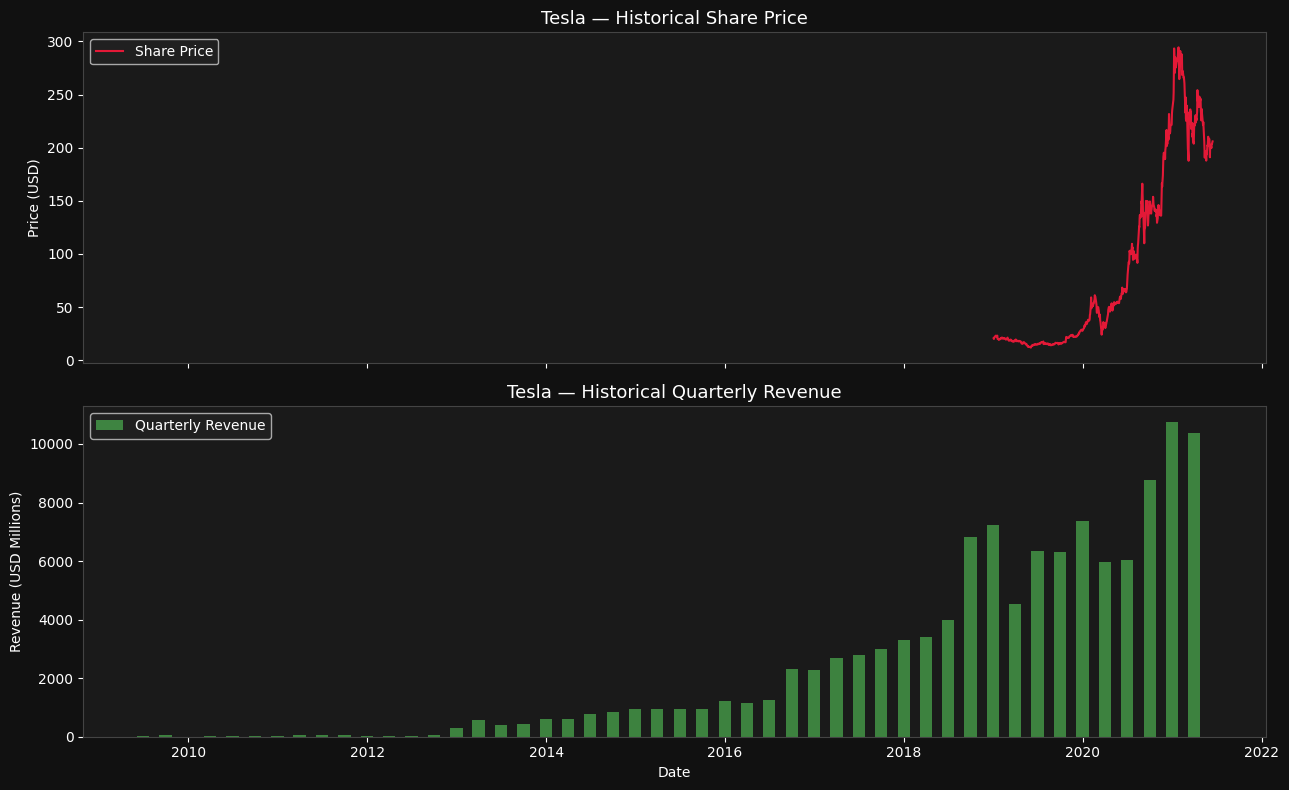

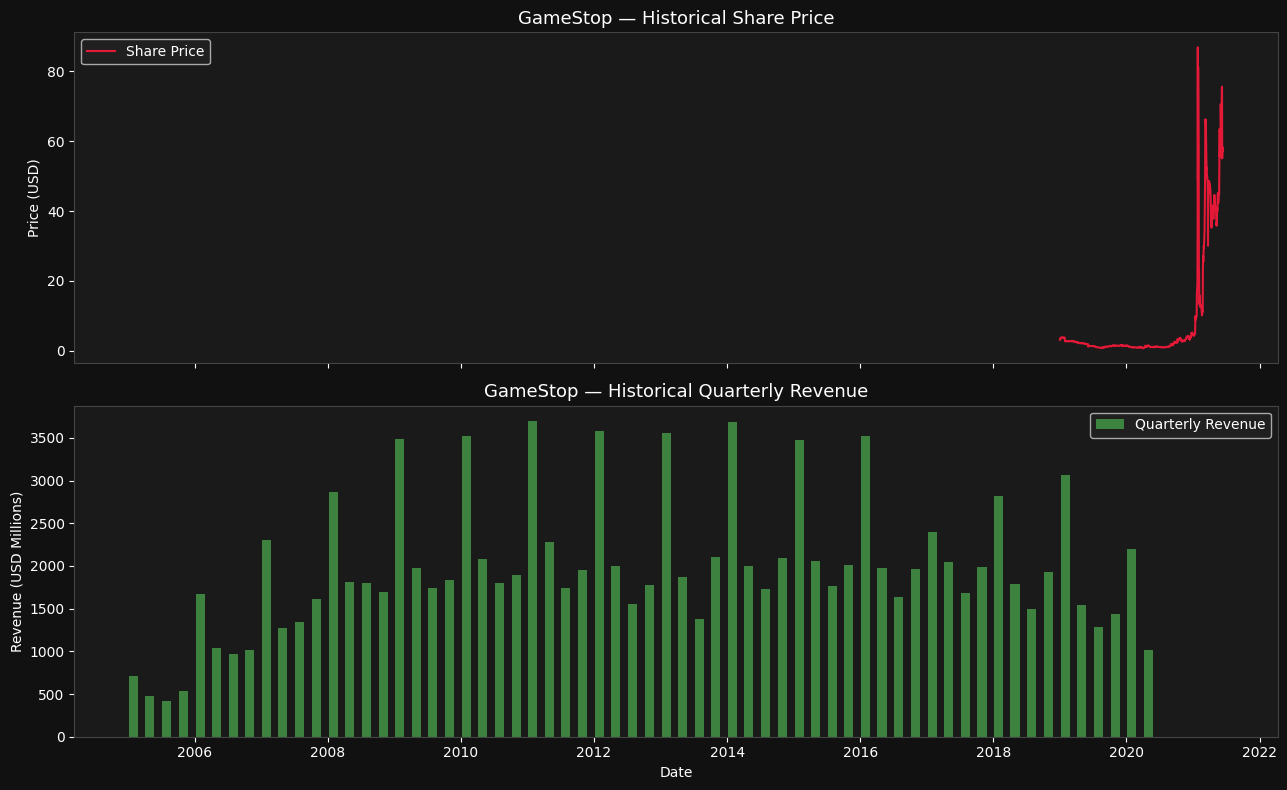

In [80]:
import matplotlib.pyplot as plt

def make_graph(stock_data: pd.DataFrame, revenue_data: pd.DataFrame, stock: str) -> None:
    """
    Legacy dual-panel static chart from the original IBM course assignment.
    Preserved for rubric compatibility. Shows data through June 2021.

    Parameters
    ----------
    stock_data   : pd.DataFrame – Must contain 'Date' and 'Close' columns
    revenue_data : pd.DataFrame – Must contain 'Date' and 'Revenue' columns
    stock        : str          – Display name for the stock (e.g. 'Tesla')
    """
    stock_data_specific   = stock_data[stock_data["Date"] <= "2021-06-14"].copy()
    revenue_data_specific = revenue_data[revenue_data["Date"] <= "2021-04-30"].copy()

    # Validate required columns
    for col in ["Date", "Close"]:
        if col not in stock_data_specific.columns:
            print(f"ERROR: stock_data missing column '{col}'")
            return
    for col in ["Date", "Revenue"]:
        if col not in revenue_data_specific.columns:
            print(f"ERROR: revenue_data missing column '{col}'")
            return

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    fig.patch.set_facecolor("#111111")
    for ax in axes:
        ax.set_facecolor("#1a1a1a")

    # Stock price panel
    axes[0].plot(pd.to_datetime(stock_data_specific["Date"]),
                 stock_data_specific["Close"].astype(float),
                 color="#E31937", linewidth=1.5, label="Share Price")
    axes[0].set_ylabel("Price (USD)", color="white")
    axes[0].set_title(f"{stock} — Historical Share Price", color="white", fontsize=13)
    axes[0].tick_params(colors="white")
    axes[0].spines[:].set_color("#444")
    axes[0].legend(facecolor="#222", labelcolor="white")

    # Revenue panel
    axes[1].bar(pd.to_datetime(revenue_data_specific["Date"]),
                revenue_data_specific["Revenue"].astype(float),
                color="#4CAF50", alpha=0.7, width=50, label="Quarterly Revenue")
    axes[1].set_ylabel("Revenue (USD Millions)", color="white")
    axes[1].set_xlabel("Date", color="white")
    axes[1].set_title(f"{stock} — Historical Quarterly Revenue", color="white", fontsize=13)
    axes[1].tick_params(colors="white")
    axes[1].spines[:].set_color("#444")
    axes[1].legend(facecolor="#222", labelcolor="white")

    plt.tight_layout()
    plt.show()


# ─── Run for grading (Questions 5 & 6) ──────────────────────────────────────
if "TSLA" in all_price_frames and "TSLA" in revenue_data:
    make_graph(all_price_frames["TSLA"], revenue_data["TSLA"], "Tesla")

if "GME" in all_price_frames and "GME" in revenue_data:
    make_graph(all_price_frames["GME"], revenue_data["GME"], "GameStop")
